In [1]:
import pandas as pd
from IPython.display import Markdown as md
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_og = pd.read_csv('../data/csv/porsche_data.csv')
df = df_og.copy()

# Delete all row with any empty columns
df.dropna(inplace=True)

# Remove suspicious non-car listing
row_index = df.loc[df['price_now'] == df['price_now'].min()].index
df = df.drop(index=row_index)

# Delete rows with 'insufficient_data' in column price_3_years_ago
df = df[df['price_3_years_ago'] != 'insufficient_data']

df.head()

,id,model_year,model_type,mileage,condition,price_now,price_3_years_ago,appreciated,image_paths,seller_description,source
0,p00001,1987.0,944,132000.0,Fair,16250.0,13944,yes,"[""project/data/images/p00001_image_1.jpg"", ""pr...",project/data/descriptions/p00001_seller_descri...,https://bringatrailer.com/listing/1987-porsche...
1,p00002,1970.0,911,93000.0,Fair,84050.0,76500,yes,"[""project/data/images/p00002_image_1.jpg"", ""pr...",project/data/descriptions/p00002_seller_descri...,https://bringatrailer.com/listing/1970-porsche...
2,p00003,1970.0,911,2.0,Excellent,500000.0,73000,yes,"[""project/data/images/p00003_image_1.jpg"", ""pr...",project/data/descriptions/p00003_seller_descri...,https://bringatrailer.com/listing/1966-porsche...
3,p00004,2018.0,911,1200.0,Fair,435000.0,322000,yes,"[""project/data/images/p00004_image_1.jpg"", ""pr...",project/data/descriptions/p00004_seller_descri...,https://bringatrailer.com/listing/2018-porsche...
4,p00005,1965.0,356,148.0,Excellent,755000.0,4500,yes,"[""project/data/images/p00005_image_1.jpg"", ""pr...",project/data/descriptions/p00005_seller_descri...,https://bringatrailer.com/listing/1965-porsche...


In [3]:
# Count no. of Appreciated and Depreciated listings
app_count = 0
dep_count = 0

for i in df['appreciated']:
    if i == 'yes':
        app_count += 1
    else:
        dep_count += 1

# Mean mileage
mean_mileage = df['mileage'].mean()

# Mean price
mean_price = df['price_now'].mean()

display(md(f"""# Exploratory Data Analysis (EDA)
After deleting the rows with empty 'model_year' columns, there are **{len(df)}** rows.
**{app_count}** listings are appreciated, while **{dep_count}** listings are depreciated since 2022.
The mean mileage is **{round(mean_mileage)}** miles. The mean price is **USD {round(mean_price, 2)}**
"""))

# Exploratory Data Analysis (EDA)
After deleting the rows with empty 'model_year' columns, there are **1219** rows.
**614** listings are appreciated, while **605** listings are depreciated since 2022.
The mean mileage is **42337** miles. The mean price is **USD 186207.61**


Based on the scatter plot, high mileage cars generally appreciate.

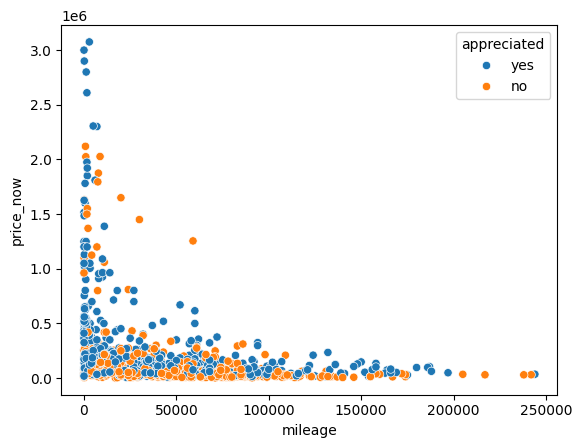

In [4]:
# Do high mileage cars depreciate?
# Scatter plot: Mileage (x-axis) vs. Price (y-axis). Color by appreciated/depreciated
sns.scatterplot(data=df, x='mileage', y='price_now', hue='appreciated')
display(md(
    'Based on the scatter plot, high mileage cars generally appreciate.'
))

The model that has the most number of cars with apppreiated value is the **911**, produced in the year **2019**.

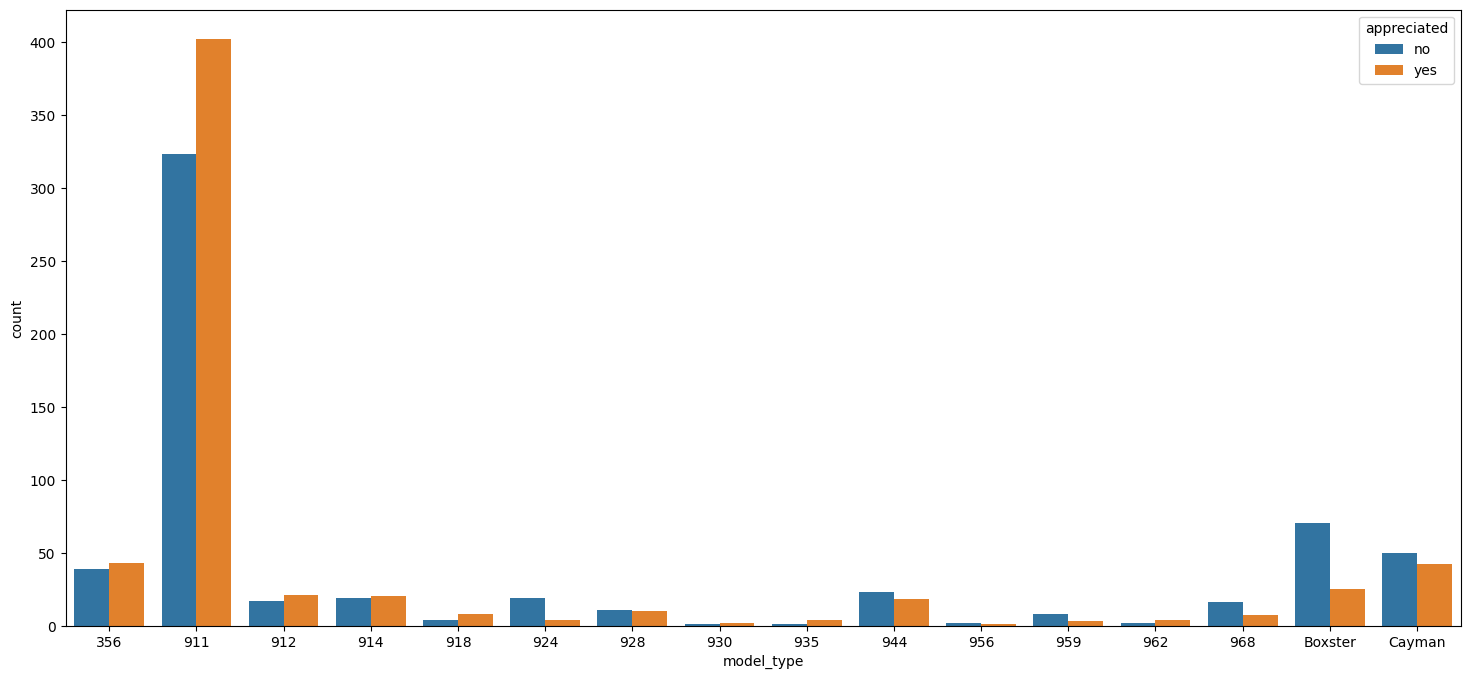

In [5]:
# Which model appreciates the most?
# Bar chart: Count by model type (911, Cayman, Boxster)
plt.figure(figsize=(18,8))
model_type_count = df.groupby(['model_type', 'appreciated']).size().reset_index(name='count')
sns.barplot(data=model_type_count, x='model_type', y='count', hue='appreciated')

app_model = model_type_count[model_type_count['appreciated'] == 'yes'].nlargest(1, 'count')['model_type'].values[0]           # model that appreciated the most

app_model_cars = df[(df['model_type'] == app_model) & (df['appreciated'] == 'yes')]             # if model_type is equal to the top appreciated model (app_model) AND yes it's appreciated
model_year_counts = app_model_cars.groupby('model_year').size()                                 # no. of rows of app_model_cars
app_model_year = model_year_counts.idxmax()

display(md(
    f'The model that has the most number of cars with apppreiated value is the **{app_model}**, produced in the year **{round(app_model_year)}**.'
))

Based on the histogram, newer Porsches are in my dataset, particularly Porsches produced between the years **2015** and **2025**.

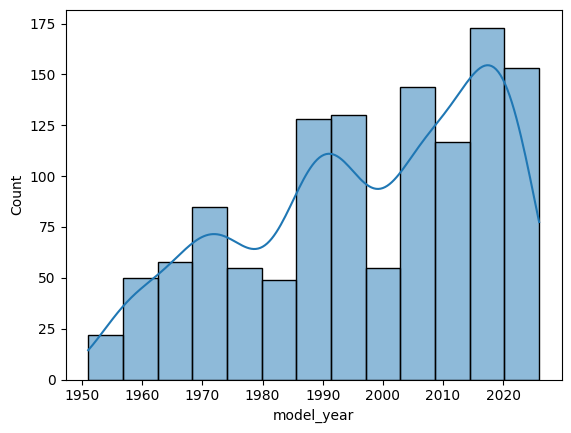

In [6]:
# Are newer or older Porsches in your dataset?
# Histogram: Age distribution.

fix, ax = plt.subplots()
sns.histplot(data=df, x='model_year', kde=True)

display(md(
    'Based on the histogram, newer Porsches are in my dataset, particularly Porsches produced between the years **2015** and **2025**.'
))

Based on the box plot, the "Excellent" condition commands higher prices.

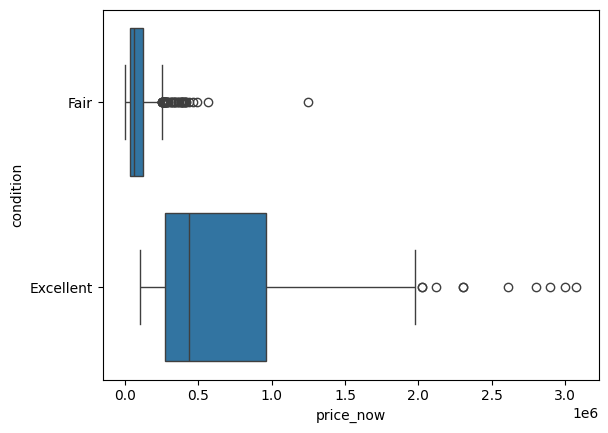

In [7]:
# Does "Excellent" condition command higher prices?
# Box plot: Price by condition

sns.boxplot(data=df, x='price_now', y='condition')
display(md(
    'Based on the box plot, the "Excellent" condition commands higher prices.'
))

# Correlation Analysis

Based on the correlation heatmap, the listing's condition has the correlation coefficient of **0.64** (positive correlation) with the listing's price. This means that the **better** the condition of the car, the **higher** the bid/sale price.
Furthermore, the listing's condition has the correlation coefficient of **0.55** (positive correlation) with the listing's price from three years ago. This means that the **better** the condition of the car, the **higher** the bid/sale price from three years ago.

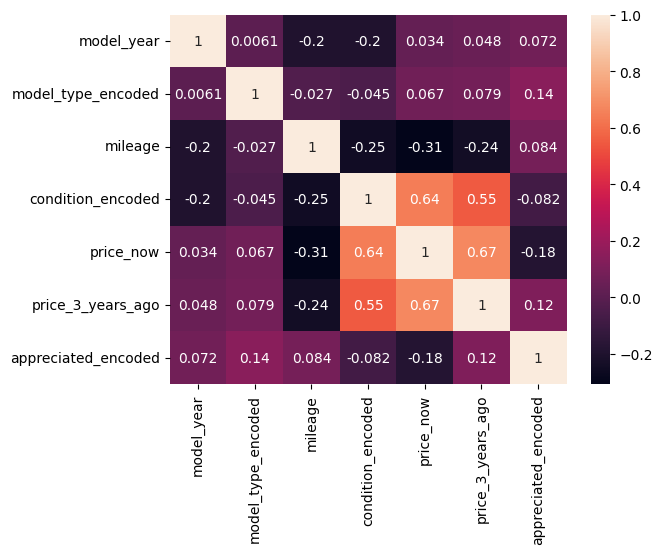

In [8]:
# Which features correlate most strongly with appreciation?
# Encode categorical columns
df['model_type_encoded'] = pd.factorize(df['model_type'])[0]
df['condition_encoded'] = pd.factorize(df['condition'])[0]
df['appreciated_encoded'] = pd.factorize(df['appreciated'])[0]
corr_columns = ['model_year','model_type_encoded','mileage','condition_encoded','price_now','price_3_years_ago','appreciated_encoded']

# Manage 'insufficient_data' in price_3_years_ago column
corr_matrix = df[corr_columns].corr()
sns.heatmap(data=corr_matrix, annot=True)

display(md(
    f'Based on the correlation heatmap, the listing\'s condition has the correlation coefficient of **0.64** (positive correlation) with the listing\'s price. This means that the **better** the condition of the car, the **higher** the bid/sale price.\nFurthermore, the listing\'s condition has the correlation coefficient of **0.55** (positive correlation) with the listing\'s price from three years ago. This means that the **better** the condition of the car, the **higher** the bid/sale price from three years ago.'
))

## So What *Drives* A Porsche's Value Of Appreciation Over Time?

1. Condition
2. Model type
3. Mileage

**Condition** is the strongest driver of appreciation. The correlation heatmap shows condition has a 0.64 correlation with current price and 0.55 with price three years ago, indicating better condition **consistently commands** higher prices. The box plot confirms that **"Excellent" condition cars achieve the highest prices**.

**Model type** also matters: the **911** has the most appreciated listings, with certain model years showing stronger appreciation.

Interestingly, **higher mileage** cars tend to **appreciate**, suggesting rarity and collectibility can outweigh wear.

The dataset is dominated by newer Porsches (2015–2020), which may reflect market dynamics where **newer models** with **strong condition** and desirable specifications **appreciate**. Overall, **condition** is the primary factor, with **model type** (especially 911) and specific **model years** also contributing to appreciation.


In [82]:
# EDA for images
## IMPORT PACKAGES
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from tqdm import tqdm
import ast

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "C:\Users\Nadra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [31]:
# Check how many listings have images, and how many
def parse_image_paths(path):
    if pd.isna(path) or path == '':
        # If there's no image path for that listing, return an empty list
        return []
    
    if isinstance(path, str):
        # Check that image_path is a string, then convert it to a Python list
        return ast.literal_eval(path)
    if isinstance(path, list):
        return path



# Count images per listing
# Create new col 'image_count' and add the image count in there
df['image_count'] = df['image_paths'].apply(lambda x: len(parse_image_paths(x)))
# Remove all listings with NO images
df = df[df['image_count'] > 0]

display(md(
    f'Total listings with images: {len(df)}'
))

Total listings with images: 1219

In [43]:
print('Image count stats:')
print(df['image_count'].describe())

print('\n... by condition:')
print(df.groupby('condition')['image_count'].describe())

print('\n... by model_type:')
print(df.groupby('model_type')['image_count'].describe())

Image count stats:
count    1219.000000
mean       11.990156
std         0.214196
min         6.000000
25%        12.000000
50%        12.000000
75%        12.000000
max        12.000000
Name: image_count, dtype: float64

... by condition:
            count      mean       std   min   25%   50%   75%   max
condition                                                          
Excellent   196.0  12.00000  0.000000  12.0  12.0  12.0  12.0  12.0
Fair       1023.0  11.98827  0.233788   6.0  12.0  12.0  12.0  12.0

... by model_type:
            count       mean       std   min   25%   50%   75%   max
model_type                                                          
356          82.0  12.000000  0.000000  12.0  12.0  12.0  12.0  12.0
911         725.0  12.000000  0.000000  12.0  12.0  12.0  12.0  12.0
912          38.0  12.000000  0.000000  12.0  12.0  12.0  12.0  12.0
914          39.0  12.000000  0.000000  12.0  12.0  12.0  12.0  12.0
918          12.0  12.000000  0.000000  12.0  12.0  12

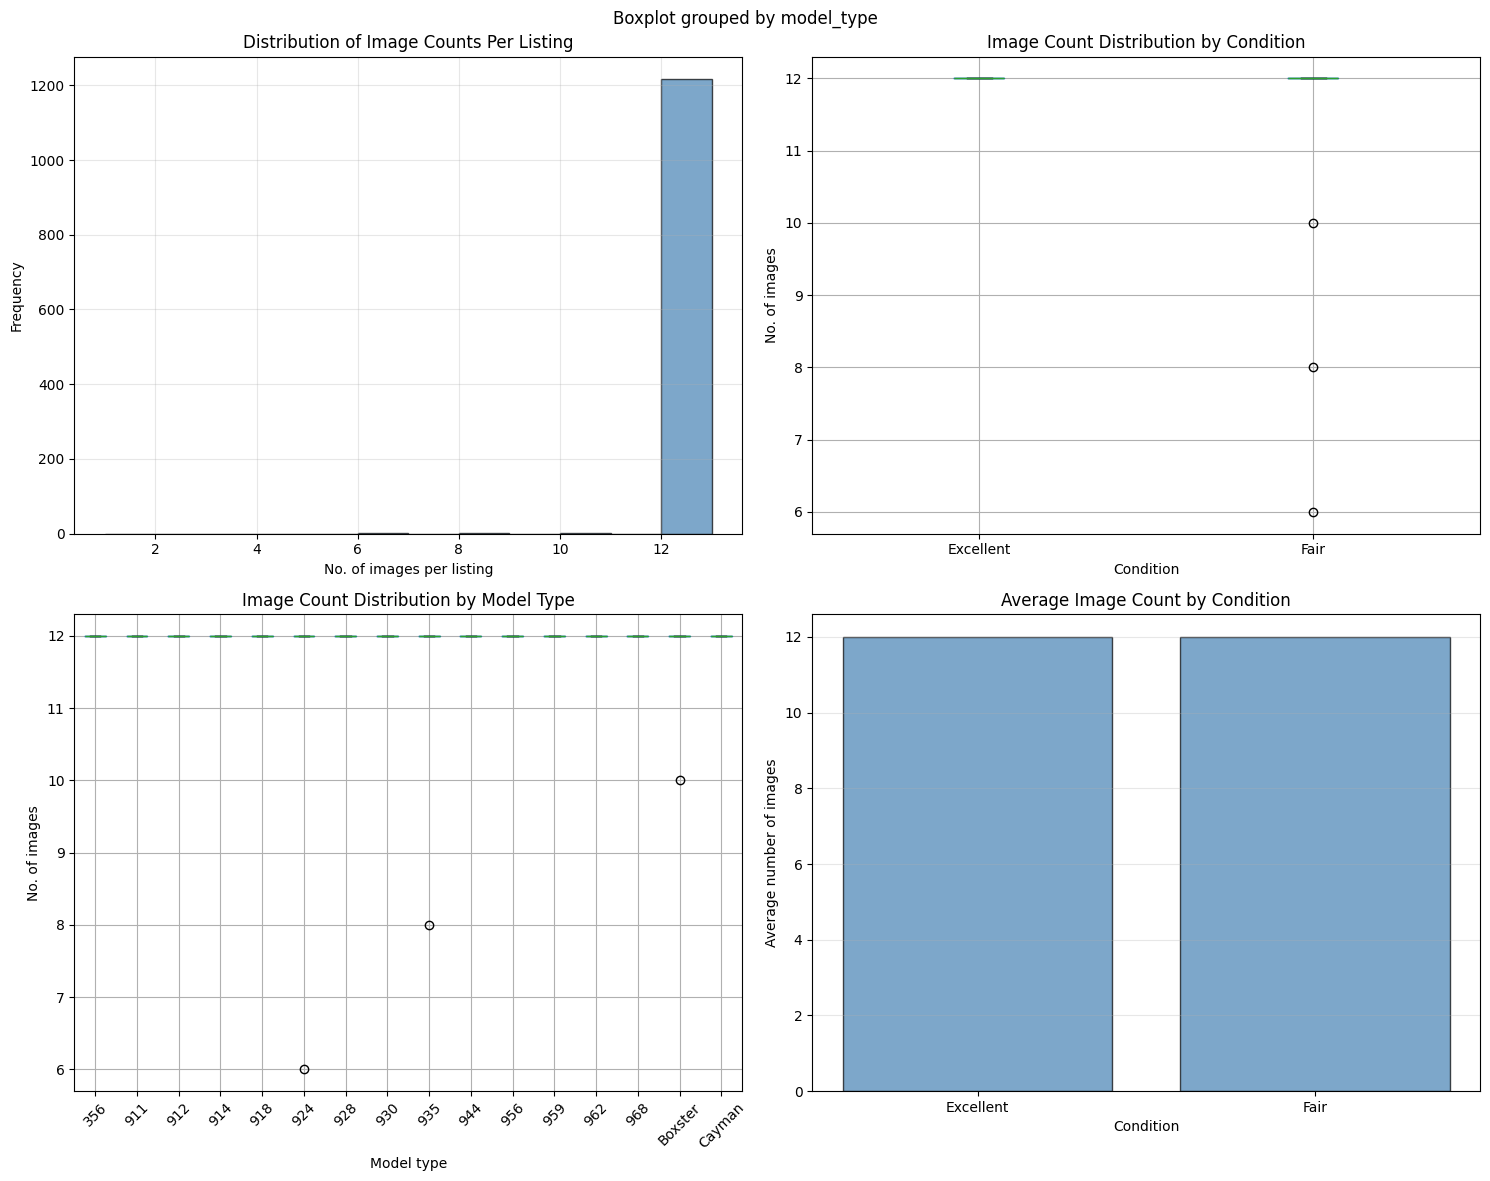

Based on the visualisations, we can see the distribution of image counts across listings and how they vary by **condition** and **model_type**. The graphs show a strong pattern: most listings have 12 images, with few exceptions. The histogram shows over 1,100 listings at 12 images, while counts of 6, 8, and 10 are rare.

By condition, all "Excellent" listings have 12 images, while "Fair" listings mostly have 12 with a few outliers at 6, 8, and 10.

By model type, most models (356, 911, 912, 914, 918, 928, 930, 944, 956, 959, 962, 968, Cayman) have all listings at 12 images; 924, 935, and Boxster have occasional outliers with fewer images. The average image count is 12 for both conditions, indicating a consistent standard across the dataset.

In [79]:
# Visualise image count distribution (above cell)
# Create a set of graphs - 2 rows, 3 columns
fix, axes = plt.subplots(2,2,figsize=(15,12))

# 1. Histogram - image counts
axes[0,0].hist(df['image_count'],
               bins=range(1, df['image_count'].max()+2),
               edgecolor='black', alpha=0.7, color='steelblue')
# Add x and y labels
axes[0,0].set_xlabel('No. of images per listing')
axes[0,0].set_ylabel('Frequency')
# Add graph title
axes[0,0].set_title('Distribution of Image Counts Per Listing')
axes[0,0].grid(True, alpha=.3)

# 2. Box plot by condition
df.boxplot(column='image_count', by='condition', ax=axes[0,1])
# Add x and y labels
axes[0,1].set_xlabel('Condition')
axes[0,1].set_ylabel('No. of images')
# Add graph title
axes[0,1].set_title('Image Count Distribution by Condition')

# 3. Box plot by model_type
df.boxplot(column='image_count', by='model_type', ax=axes[1,0])
# Add graph title
axes[1,0].set_title('Image Count Distribution by Model Type')
# Add x and y labels
axes[1,0].set_xlabel('Model type')
axes[1,0].set_ylabel('No. of images')
# Rotate x labels
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Bar chart of avg. image count by condition
avg_by_condition = df.groupby('condition')['image_count'].mean()
axes[1,1].bar(avg_by_condition.index, avg_by_condition.values,
              color='steelblue', alpha=.7, edgecolor='black')
# Set x and y labels
axes[1,1].set_xlabel('Condition')
axes[1,1].set_ylabel('Average number of images')
# Set graph title
axes[1,1].set_title('Average Image Count by Condition')
axes[1,1].grid(True, alpha=.3, axis='y')



plt.tight_layout()
# plt.savefig('../../graphs/distribution_image_counts.png', dpi=300, bbox_inches='tight')
plt.show()
display(md(
    'Based on the visualisations, we can see the distribution of image counts across listings and how they vary by **condition** and **model_type**. The graphs show a strong pattern: most listings have 12 images, with few exceptions. The histogram shows over 1,100 listings at 12 images, while counts of 6, 8, and 10 are rare.\n\nBy condition, all "Excellent" listings have 12 images, while "Fair" listings mostly have 12 with a few outliers at 6, 8, and 10.\n\nBy model type, most models (356, 911, 912, 914, 918, 928, 930, 944, 956, 959, 962, 968, Cayman) have all listings at 12 images; 924, 935, and Boxster have occasional outliers with fewer images. The average image count is 12 for both conditions, indicating a consistent standard across the dataset.'
))

In [ ]:
# Vision feature extraction setup